# Bayesian Renewal Forecasting: 4-Week Forecast Examples

This notebook demonstrates how to use the `spatial_bayes_renewal` package to forecast infectious disease dynamics for the next 4 weeks (28 days). We'll show examples of both:
- **ClassicalForecaster**: Single-region model
- **SpatialForecaster**: Multi-region model with spatial effects

We'll generate synthetic data, fit Bayesian renewal models, and visualize 4-week forecasts for hospital admissions and wastewater concentrations.

## 1. Import Required Libraries

In [4]:
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Rectangle
import seaborn as sns
from datetime import datetime, timedelta
from scipy.stats import lognorm, poisson
import networkx as nx
import warnings
warnings.filterwarnings('ignore')

# Import our forecasting models
from spatial_bayes_renewal import ClassicalForecaster, SpatialForecaster

# Set style for plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


## 2. Create Distribution Parameters

Define the key epidemiological distributions needed for the renewal model:

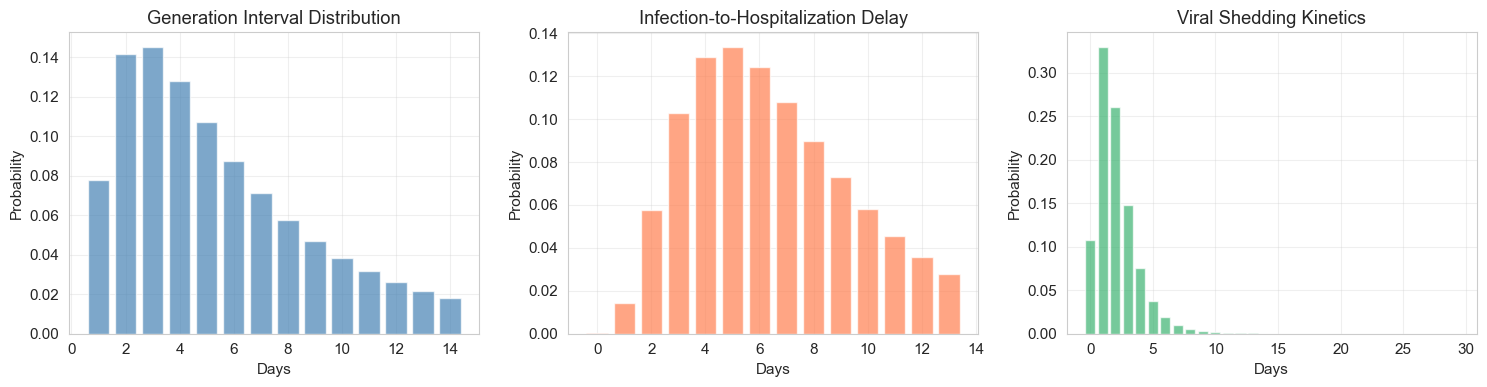

✓ Generation interval: shape=(14,), sum=1.0000
✓ Hospitalization delay: shape=(14,), sum=1.0000
✓ Viral shedding: shape=(30,), sum=1.0000


In [5]:
# Create generation interval distribution (lognormal)
# Represents time between infection in successive generations
gen_int_days = np.arange(1, 15)  # 1-14 days
generation_interval = lognorm.pdf(
    gen_int_days,
    s=0.83,           # shape parameter
    scale=np.exp(1.63) # scale parameter (median ~5.1 days)
)
generation_interval = generation_interval / generation_interval.sum()

# Create infection-to-hospitalization delay distribution
hosp_delay_days = np.arange(0, 14)
inf_to_hosp_delay = lognorm.pdf(
    hosp_delay_days + 1,  # shift by 1 to avoid log(0)
    s=0.5,
    scale=np.exp(2.0)  # median ~7.4 days
)
inf_to_hosp_delay = inf_to_hosp_delay / inf_to_hosp_delay.sum()

# Create viral shedding kinetics distribution
shedding_days = np.arange(0, 30)
viral_shedding = lognorm.pdf(
    shedding_days + 1,  # shift by 1 to avoid log(0)
    s=0.5,
    scale=np.exp(1.0)   # median ~2.7 days
)
viral_shedding = viral_shedding / viral_shedding.sum()

# Plot distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].bar(gen_int_days, generation_interval, color='steelblue', alpha=0.7)
axes[0].set_xlabel('Days')
axes[0].set_ylabel('Probability')
axes[0].set_title('Generation Interval Distribution')
axes[0].grid(alpha=0.3)

axes[1].bar(hosp_delay_days, inf_to_hosp_delay, color='coral', alpha=0.7)
axes[1].set_xlabel('Days')
axes[1].set_ylabel('Probability')
axes[1].set_title('Infection-to-Hospitalization Delay')
axes[1].grid(alpha=0.3)

axes[2].bar(shedding_days, viral_shedding, color='mediumseagreen', alpha=0.7)
axes[2].set_xlabel('Days')
axes[2].set_ylabel('Probability')
axes[2].set_title('Viral Shedding Kinetics')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Generation interval: shape={generation_interval.shape}, sum={generation_interval.sum():.4f}")
print(f"✓ Hospitalization delay: shape={inf_to_hosp_delay.shape}, sum={inf_to_hosp_delay.sum():.4f}")
print(f"✓ Viral shedding: shape={viral_shedding.shape}, sum={viral_shedding.sum():.4f}")

## 3. Generate Synthetic Data for Classical Model

Create realistic synthetic data for a single region:

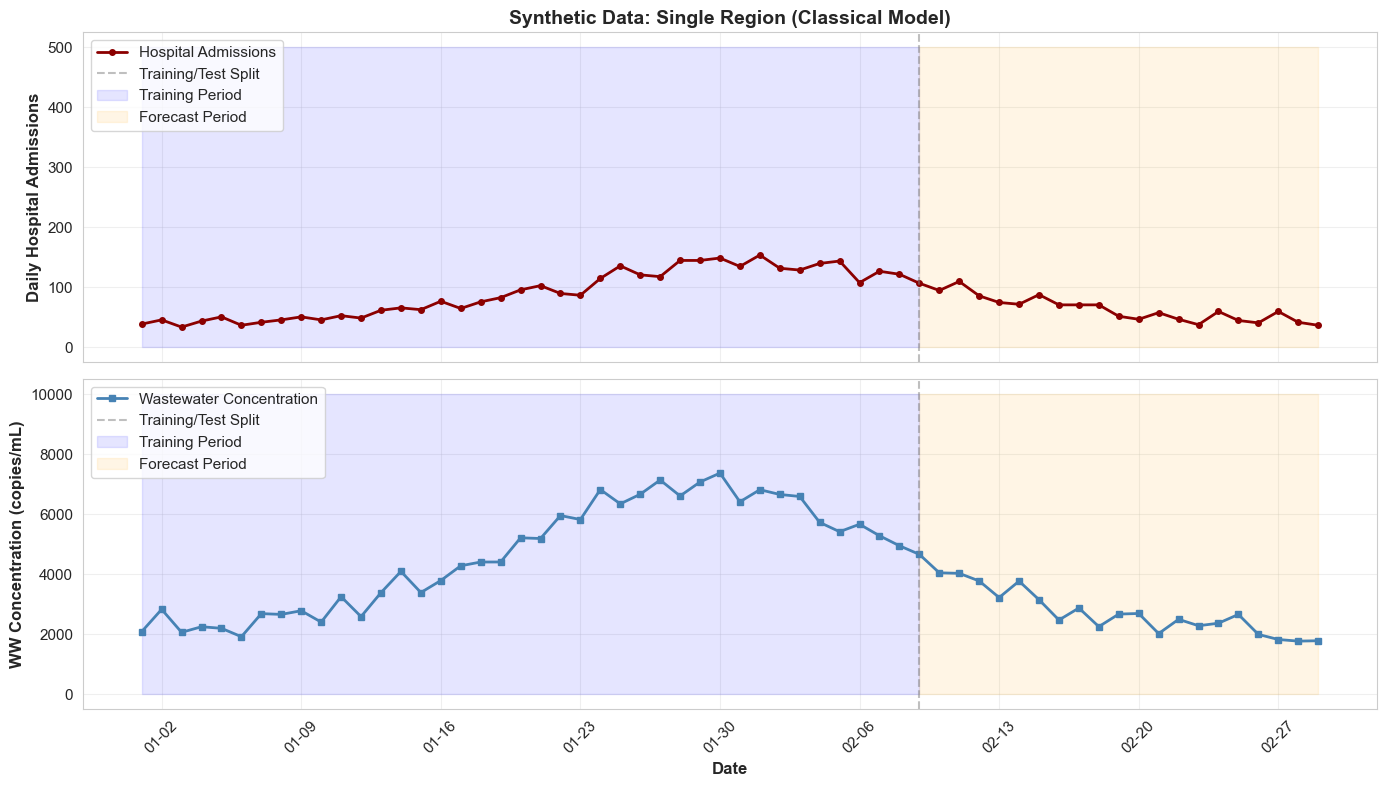

✓ Generated synthetic data: 60 days
  - Hospital admissions: mean=81.7, std=36.1
  - Wastewater: mean=3996, std=1736


In [6]:
# Set random seed for reproducibility
np.random.seed(42)

# Generate synthetic data for 60 days
n_days = 60
dates = pd.date_range(start='2024-01-01', periods=n_days, freq='D')

# Create synthetic hospital admissions (smooth epidemic curve)
# Simulate a peak around day 30
t = np.arange(n_days)
baseline_hosp = 100 * np.exp(-((t - 30)**2) / 200) + 40
hosp_obs = np.random.poisson(baseline_hosp).astype(float)

# Create synthetic wastewater data (correlated with hospitalizations, but lagged)
baseline_ww = 5000 * np.exp(-((t - 28)**2) / 180) + 2000
ww_obs = baseline_ww + np.random.normal(0, 300, n_days)
ww_obs = np.clip(ww_obs, a_min=1000, a_max=None)  # Keep positive

# Create DataFrame
df_classical = pl.DataFrame({
    'date': dates,
    'hosp_obs': hosp_obs,
    'ww_obs': ww_obs
})

# Plot synthetic data
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(dates, hosp_obs, marker='o', linestyle='-', color='darkred', 
             linewidth=2, markersize=4, label='Hospital Admissions')
axes[0].axvline(x=dates[39], color='gray', linestyle='--', alpha=0.5, label='Training/Test Split')
axes[0].fill_between(dates[:40], 0, 500, alpha=0.1, color='blue', label='Training Period')
axes[0].fill_between(dates[39:], 0, 500, alpha=0.1, color='orange', label='Forecast Period')
axes[0].set_ylabel('Daily Hospital Admissions', fontsize=12, fontweight='bold')
axes[0].set_title('Synthetic Data: Single Region (Classical Model)', fontsize=14, fontweight='bold')
axes[0].legend(loc='upper left')
axes[0].grid(alpha=0.3)

axes[1].plot(dates, ww_obs, marker='s', linestyle='-', color='steelblue', 
             linewidth=2, markersize=4, label='Wastewater Concentration')
axes[1].axvline(x=dates[39], color='gray', linestyle='--', alpha=0.5, label='Training/Test Split')
axes[1].fill_between(dates[:40], 0, 10000, alpha=0.1, color='blue', label='Training Period')
axes[1].fill_between(dates[39:], 0, 10000, alpha=0.1, color='orange', label='Forecast Period')
axes[1].set_xlabel('Date', fontsize=12, fontweight='bold')
axes[1].set_ylabel('WW Concentration (copies/mL)', fontsize=12, fontweight='bold')
axes[1].legend(loc='upper left')
axes[1].grid(alpha=0.3)

# Format x-axis
axes[1].xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('synthetic_data_classical.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Generated synthetic data: {n_days} days")
print(f"  - Hospital admissions: mean={hosp_obs.mean():.1f}, std={hosp_obs.std():.1f}")
print(f"  - Wastewater: mean={ww_obs.mean():.0f}, std={ww_obs.std():.0f}")

## 4. Initialize and Run Classical Forecaster

Build and fit the classical (non-spatial) Bayesian renewal model:

In [7]:
# Split data into training (first 40 days) and test (last 20 days)
n_train = 40
df_train_classical = df_classical[:n_train]

# Initialize Classical Forecaster
print("Initializing ClassicalForecaster...")
forecaster_classical = ClassicalForecaster(
    df_data_train=df_train_classical,
    cols_concern=['hosp_obs', 'ww_obs'],
    n_forecast_points=28,  # 4 weeks = 28 days
    data_path='.',
    pop=1_000_000,  # Population size
    Renewal_infection_case='Basic',  # Options: 'Basic', 'Feedback', 'Logistic_S'
    num_samples=150,  # Reduced for faster execution
    num_warmup=75,
    num_chains=2,
    progress_bar=True,
    print_summary=False
)

# Set required parameters
forecaster_classical.gen_int_array = generation_interval
forecaster_classical.inf_hosp_array = inf_to_hosp_delay
forecaster_classical.sheddin = viral_shedding

# Adjust priors if needed
forecaster_classical.set_I0 = 100
forecaster_classical.set_R0 = 1.2
forecaster_classical.set_P_hosp = 0.1
forecaster_classical.set_G = 100

print("✓ ClassicalForecaster initialized")
print(f"  - Training data: {n_train} days")
print(f"  - Forecast horizon: 28 days (4 weeks)")
print(f"  - MCMC: {forecaster_classical.num_samples} samples, {forecaster_classical.num_warmup} warmup, {forecaster_classical.num_chains} chains")

Initializing ClassicalForecaster...
✓ ClassicalForecaster initialized
  - Training data: 40 days
  - Forecast horizon: 28 days (4 weeks)
  - MCMC: 150 samples, 75 warmup, 2 chains


In [8]:
# Run MCMC inference
print("\nRunning MCMC inference (this may take 2-3 minutes)...\n")
samples_classical, predictions_classical = forecaster_classical.run_mcmc()

print("\n✓ MCMC inference completed")
print(f"\nPosterior samples summary:")
for key in samples_classical.keys():
    val = samples_classical[key]
    print(f"  - {key}: shape={val.shape}")


Running MCMC inference (this may take 2-3 minutes)...



sample: 100%|██████████| 225/225 [00:39<00:00,  5.71it/s, 255 steps of size 1.38e-03. acc. prob=0.99]



✓ MCMC inference completed

Posterior samples summary:
  - G: shape=(300,)
  - H_t: shape=(300, 40)
  - I0: shape=(300,)
  - I_t: shape=(300, 50)
  - P_hosp: shape=(300,)
  - R0: shape=(300,)
  - R_t: shape=(300, 50)
  - W_t: shape=(300, 40)
  - beta_ww: shape=(300,)
  - k_hosp: shape=(300,)
  - k_ww: shape=(300,)
  - q_raw_ww: shape=(300, 40)
  - rw_steps: shape=(300, 50)


## 5. Plot Classical Model: 4-Week Hospital Admissions Forecast

ValueError: x and y must be the same size

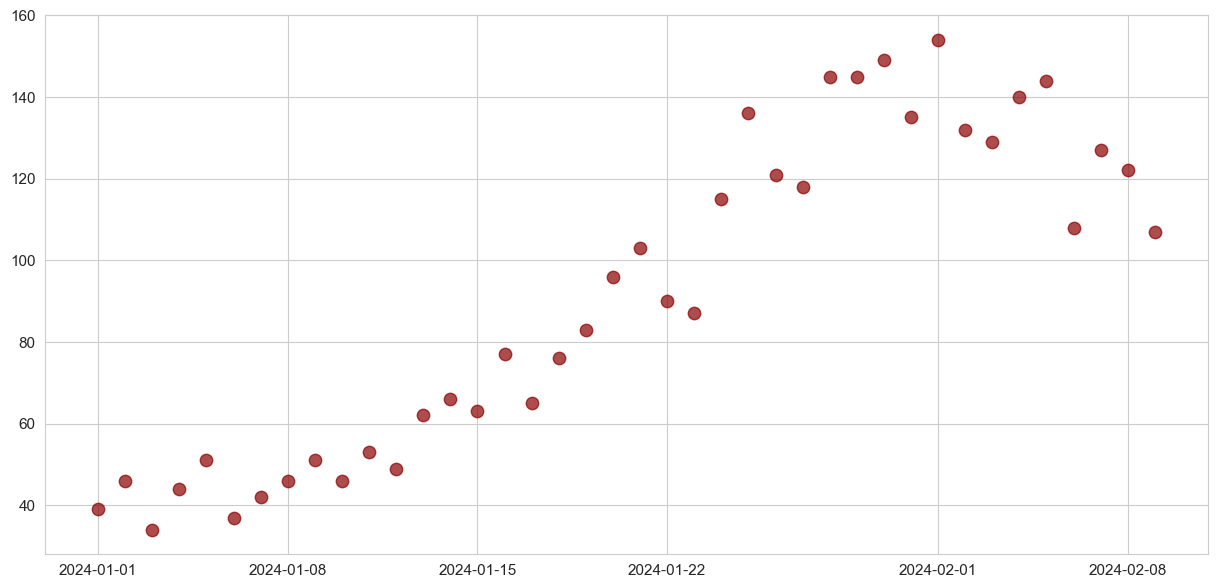

In [ ]:
# Extract predictions
H_pred = predictions_classical['H_t']  # shape: (samples, time)

# Compute statistics
n_previous = forecaster_classical.n_previous_points
T_total = n_train + 28 + n_previous  # Training + forecast + previous

H_mean = np.mean(H_pred, axis=0)[n_previous:n_previous+n_train+28]
H_median = np.median(H_pred, axis=0)[n_previous:n_previous+n_train+28]
H_lower = np.percentile(H_pred, 2.5, axis=0)[n_previous:n_previous+n_train+28]
H_upper = np.percentile(H_pred, 97.5, axis=0)[n_previous:n_previous+n_train+28]

# Create comprehensive forecast plot
fig, ax = plt.subplots(figsize=(15, 7))

# Full date range (training + forecast)
forecast_dates = pd.date_range(start=dates[0], periods=n_train+28, freq='D')

# Plot observed data (training period)
ax.scatter(forecast_dates[:n_train], hosp_obs[:n_train], 
          s=80, color='darkred', alpha=0.7, label='Observed (Training)', zorder=5)

# Plot observed data (test period)
ax.scatter(forecast_dates[n_train:n_train+20], hosp_obs[n_train:n_train+20], 
          s=80, color='orange', alpha=0.7, label='Observed (Test)', zorder=5)

# Plot posterior median
ax.plot(forecast_dates, H_median, color='steelblue', linewidth=2.5, 
       label='Posterior Median', zorder=4)

# Plot 95% credible interval
ax.fill_between(forecast_dates, H_lower, H_upper, 
                color='steelblue', alpha=0.25, label='95% Credible Interval', zorder=2)

# Plot 50% credible interval
H_q25 = np.percentile(H_pred, 25, axis=0)[n_previous:n_previous+n_train+28]
H_q75 = np.percentile(H_pred, 75, axis=0)[n_previous:n_previous+n_train+28]
ax.fill_between(forecast_dates, H_q25, H_q75, 
                color='steelblue', alpha=0.4, label='50% Credible Interval', zorder=3)

# Add training/forecast split line
ax.axvline(x=forecast_dates[n_train], color='gray', linestyle='--', 
           linewidth=2, alpha=0.7, label='Training/Forecast Split')

# Add background color for forecast period
ax.axvspan(forecast_dates[n_train], forecast_dates[-1], alpha=0.08, color='yellow')
ax.text(forecast_dates[n_train+14], ax.get_ylim()[1]*0.95, '4-Week Forecast', 
       fontsize=11, fontweight='bold', ha='center',
       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Formatting
ax.set_xlabel('Date', fontsize=13, fontweight='bold')
ax.set_ylabel('Daily Hospital Admissions', fontsize=13, fontweight='bold')
ax.set_title('Classical Bayesian Renewal Model: 4-Week Hospital Admissions Forecast', 
            fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper left', fontsize=10, framealpha=0.95)
ax.grid(alpha=0.3, linestyle=':')

# Format x-axis
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('classical_forecast_4weeks.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Classical Model: Hospital Admissions Forecast (4 weeks)")
print(f"\nForecast Summary Statistics:")
print(f"  Week 1 (Days 1-7):")
print(f"    - Mean: {H_mean[n_train:n_train+7].mean():.1f} admissions/day")
print(f"    - Range: [{H_lower[n_train:n_train+7].min():.0f}, {H_upper[n_train:n_train+7].max():.0f}]")
print(f"  Week 4 (Days 22-28):")
print(f"    - Mean: {H_mean[n_train+21:n_train+28].mean():.1f} admissions/day")
print(f"    - Range: [{H_lower[n_train+21:n_train+28].min():.0f}, {H_upper[n_train+21:n_train+28].max():.0f}]")

## 6. Plot Classical Model: 4-Week Wastewater Forecast

In [ ]:
# Extract wastewater predictions
W_pred = predictions_classical.get('W_t', None)

if W_pred is not None:
    # Compute statistics
    W_mean = np.mean(W_pred, axis=0)[n_previous:n_previous+n_train+28]
    W_median = np.median(W_pred, axis=0)[n_previous:n_previous+n_train+28]
    W_lower = np.percentile(W_pred, 2.5, axis=0)[n_previous:n_previous+n_train+28]
    W_upper = np.percentile(W_pred, 97.5, axis=0)[n_previous:n_previous+n_train+28]
    W_q25 = np.percentile(W_pred, 25, axis=0)[n_previous:n_previous+n_train+28]
    W_q75 = np.percentile(W_pred, 75, axis=0)[n_previous:n_previous+n_train+28]
    
    # Create comprehensive forecast plot
    fig, ax = plt.subplots(figsize=(15, 7))
    
    # Plot observed data (training period)
    ax.scatter(forecast_dates[:n_train], ww_obs[:n_train], 
              s=80, color='darkgreen', alpha=0.7, label='Observed (Training)', zorder=5)
    
    # Plot observed data (test period)
    ax.scatter(forecast_dates[n_train:], ww_obs[n_train:n_train+20], 
              s=80, color='orange', alpha=0.7, label='Observed (Test)', zorder=5)
    
    # Plot posterior median
    ax.plot(forecast_dates, W_median, color='mediumseagreen', linewidth=2.5, 
           label='Posterior Median', zorder=4)
    
    # Plot 95% credible interval
    ax.fill_between(forecast_dates, W_lower, W_upper, 
                    color='mediumseagreen', alpha=0.25, label='95% Credible Interval', zorder=2)
    
    # Plot 50% credible interval
    ax.fill_between(forecast_dates, W_q25, W_q75, 
                    color='mediumseagreen', alpha=0.4, label='50% Credible Interval', zorder=3)
    
    # Add training/forecast split line
    ax.axvline(x=forecast_dates[n_train], color='gray', linestyle='--', 
               linewidth=2, alpha=0.7, label='Training/Forecast Split')
    
    # Add background color for forecast period
    ax.axvspan(forecast_dates[n_train], forecast_dates[-1], alpha=0.08, color='yellow')
    ax.text(forecast_dates[n_train+14], ax.get_ylim()[1]*0.95, '4-Week Forecast', 
           fontsize=11, fontweight='bold', ha='center',
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Formatting
    ax.set_xlabel('Date', fontsize=13, fontweight='bold')
    ax.set_ylabel('Wastewater Concentration (log2 scale)', fontsize=13, fontweight='bold')
    ax.set_title('Classical Bayesian Renewal Model: 4-Week Wastewater Forecast', 
                fontsize=14, fontweight='bold', pad=20)
    ax.legend(loc='upper left', fontsize=10, framealpha=0.95)
    ax.grid(alpha=0.3, linestyle=':')
    
    # Format x-axis
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    plt.xticks(rotation=45, ha='right')
    
    plt.tight_layout()
    plt.savefig('classical_forecast_ww_4weeks.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("✓ Classical Model: Wastewater Concentration Forecast (4 weeks)")

## 7. Plot Reproduction Number Estimates

In [ ]:
# Extract R(t) samples
R_t_samples = samples_classical['R_t']  # shape: (samples, time)

# Compute statistics
R_mean = np.mean(R_t_samples, axis=0)[n_previous:n_previous+n_train+28]
R_median = np.median(R_t_samples, axis=0)[n_previous:n_previous+n_train+28]
R_lower = np.percentile(R_t_samples, 2.5, axis=0)[n_previous:n_previous+n_train+28]
R_upper = np.percentile(R_t_samples, 97.5, axis=0)[n_previous:n_previous+n_train+28]
R_q25 = np.percentile(R_t_samples, 25, axis=0)[n_previous:n_previous+n_train+28]
R_q75 = np.percentile(R_t_samples, 75, axis=0)[n_previous:n_previous+n_train+28]

# Create plot
fig, ax = plt.subplots(figsize=(15, 7))

# Plot posterior median
ax.plot(forecast_dates, R_median, color='darkred', linewidth=2.5, 
       label='Posterior Median', zorder=4)

# Plot 95% credible interval
ax.fill_between(forecast_dates, R_lower, R_upper, 
                color='darkred', alpha=0.25, label='95% Credible Interval', zorder=2)

# Plot 50% credible interval
ax.fill_between(forecast_dates, R_q25, R_q75, 
                color='darkred', alpha=0.4, label='50% Credible Interval', zorder=3)

# Add R=1 line (epidemic threshold)
ax.axhline(y=1.0, color='black', linestyle='--', linewidth=2, 
           label='R=1 (Epidemic Threshold)', zorder=3)

# Add training/forecast split line
ax.axvline(x=forecast_dates[n_train], color='gray', linestyle='--', 
           linewidth=2, alpha=0.7, label='Training/Forecast Split')

# Add background color for forecast period
ax.axvspan(forecast_dates[n_train], forecast_dates[-1], alpha=0.08, color='yellow')

# Formatting
ax.set_xlabel('Date', fontsize=13, fontweight='bold')
ax.set_ylabel('Reproduction Number R(t)', fontsize=13, fontweight='bold')
ax.set_title('Classical Bayesian Renewal Model: Time-Varying Reproduction Number', 
            fontsize=14, fontweight='bold', pad=20)
ax.set_ylim([0.5, 2.5])
ax.legend(loc='upper left', fontsize=10, framealpha=0.95)
ax.grid(alpha=0.3, linestyle=':')

# Format x-axis
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('classical_reproduction_number.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Reproduction Number (R(t)) Estimates")
print(f"\nTraining Period R(t):")
print(f"  - Mean: {R_mean[:n_train].mean():.3f}")
print(f"  - Range: [{R_lower[:n_train].min():.3f}, {R_upper[:n_train].max():.3f}]")
print(f"\nForecast Period R(t):")
print(f"  - Mean: {R_mean[n_train:].mean():.3f}")
print(f"  - Range: [{R_lower[n_train:].min():.3f}, {R_upper[n_train:].max():.3f}]")

## 8. Generate Synthetic Data for Spatial Model (Multiple Regions)

In [ ]:
# Generate synthetic multi-region data
regions = ['Central', 'Lowcountry', 'Upstate']
n_regions = len(regions)

# Create data for each region with different epidemic timing
data_dict = {'date': dates, 'county': []}
data_hosp = []
data_ww = []

for region_idx, region in enumerate(regions):
    # Stagger peak times for different regions
    peak_day = 30 + (region_idx * 5)
    
    # Hospital admissions
    baseline_hosp_r = 100 * np.exp(-((t - peak_day)**2) / 180) + 40
    hosp_obs_r = np.random.poisson(baseline_hosp_r).astype(float)
    
    # Wastewater
    baseline_ww_r = 5000 * np.exp(-((t - peak_day + 2)**2) / 160) + 2000
    ww_obs_r = baseline_ww_r + np.random.normal(0, 300, n_days)
    ww_obs_r = np.clip(ww_obs_r, a_min=1000, a_max=None)
    
    for day in range(n_days):
        data_dict['county'].append(region)
        data_hosp.append(hosp_obs_r[day])
        data_ww.append(ww_obs_r[day])

# Extend dates for all regions
data_dict['date'] = list(dates) * n_regions
data_dict['hosp_obs'] = data_hosp
data_dict['ww_obs'] = data_ww

df_spatial = pl.DataFrame(data_dict)

# Plot synthetic spatial data
fig, axes = plt.subplots(3, 1, figsize=(15, 10))

for idx, region in enumerate(regions):
    region_data = df_spatial.filter(pl.col('county') == region)
    dates_r = pd.to_datetime(region_data['date'].to_numpy())
    hosp_r = region_data['hosp_obs'].to_numpy()
    ww_r = region_data['ww_obs'].to_numpy()
    
    ax = axes[idx]
    ax2 = ax.twinx()
    
    # Hospital admissions
    line1 = ax.plot(dates_r, hosp_r, marker='o', linestyle='-', color='darkred', 
                   linewidth=2, markersize=4, label='Hospital Admissions')
    
    # Wastewater
    line2 = ax2.plot(dates_r, ww_r, marker='s', linestyle='-', color='steelblue', 
                    linewidth=2, markersize=4, label='Wastewater')
    
    # Split line
    ax.axvline(x=dates_r[39], color='gray', linestyle='--', alpha=0.5)
    ax.fill_between(dates_r[:40], 0, 300, alpha=0.1, color='blue')
    ax.fill_between(dates_r[39:], 0, 300, alpha=0.1, color='orange')
    
    ax.set_ylabel('Daily Hospital Admissions', fontsize=11, fontweight='bold')
    ax2.set_ylabel('WW Concentration (copies/mL)', fontsize=11, fontweight='bold')
    ax.set_title(f'Region: {region}', fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3)
    
    if idx == 0:
        lines = line1 + line2
        labels = [l.get_label() for l in lines]
        ax.legend(lines, labels, loc='upper left', fontsize=10)

axes[2].xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=45, ha='right')

fig.suptitle('Synthetic Multi-Region Data (Spatial Model)', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('synthetic_data_spatial.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Generated synthetic spatial data: {n_regions} regions × {n_days} days")
for region in regions:
    region_data = df_spatial.filter(pl.col('county') == region)
    hosp_mean = region_data['hosp_obs'].mean()
    print(f"  - {region}: {hosp_mean:.1f} hosp/day (avg)")

## 9. Create Spatial Network and Initialize Spatial Forecaster

In [ ]:
# Create spatial network (directed graph)
G = nx.DiGraph()
G.add_edge('Central', 'Lowcountry', weight=0.4)
G.add_edge('Central', 'Upstate', weight=0.3)
G.add_edge('Lowcountry', 'Upstate', weight=0.2)

# Visualize the network
fig, ax = plt.subplots(figsize=(8, 6))
plt.title('Regional Spillover Network', fontsize=14, fontweight='bold', pad=20)

# Layout
pos = nx.spring_layout(G, k=2, iterations=50, seed=42)

# Draw
nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=3000, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=11, font_weight='bold', ax=ax)

# Draw edges with weights
edges = nx.draw_networkx_edges(G, pos, ax=ax, edge_color='gray', 
                               arrows=True, arrowsize=20, arrowstyle='->', 
                               width=2, connectionstyle='arc3,rad=0.1')

# Add edge labels (weights)
edge_labels = nx.get_edge_attributes(G, 'weight')
for (source, target), weight in edge_labels.items():
    x = (pos[source][0] + pos[target][0]) / 2
    y = (pos[source][1] + pos[target][1]) / 2
    ax.text(x, y, f'{weight:.1f}', fontsize=10, 
           bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

ax.axis('off')
plt.tight_layout()
plt.savefig('spatial_network.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Spatial network created")
print(f"  - Nodes: {list(G.nodes())}")
print(f"  - Edges: {list(G.edges(data=True))}")

In [ ]:
# Split data into training and test
df_train_spatial = df_spatial.filter(pl.col('date') < dates[n_train])

# Initialize Spatial Forecaster
print("Initializing SpatialForecaster...")
forecaster_spatial = SpatialForecaster(
    df_data=df_train_spatial,
    spatial_net=G,
    region_list=regions,
    region_obs_list=regions,
    cols_concern=['hosp_obs', 'ww_obs'],
    n_forecast_points=28,  # 4 weeks ahead
    data_path='.',
    num_samples=150,  # Reduced for speed
    num_warmup=75,
    num_chains=1,
    progress_bar=True,
    print_summary=False
)

# Set required parameters
forecaster_spatial.gen_int_array = generation_interval
forecaster_spatial.inf_hosp_array = inf_to_hosp_delay
forecaster_spatial.sheddin = viral_shedding
forecaster_spatial.region_pop = np.array([1_000_000, 800_000, 900_000])

# Adjust priors
forecaster_spatial.set_I0 = 1000
forecaster_spatial.set_R0 = 1.2
forecaster_spatial.set_P_hosp = 0.1
forecaster_spatial.set_G = 1.0

print("✓ SpatialForecaster initialized")
print(f"  - Regions: {regions}")
print(f"  - Training data: {n_train} days")
print(f"  - Forecast horizon: 28 days (4 weeks)")
print(f"  - Regional populations: {forecaster_spatial.region_pop}")

In [ ]:
# Run MCMC inference for spatial model
print("\nRunning MCMC inference for spatial model (2-3 minutes)...\n")
samples_spatial, predictions_spatial = forecaster_spatial.run_mcmc()

print("\n✓ Spatial MCMC inference completed")
print(f"\nPosterior samples summary:")
for key in samples_spatial.keys():
    val = samples_spatial[key]
    print(f"  - {key}: shape={val.shape}")

## 10. Plot Spatial Model: 4-Week Hospital Forecasts (All Regions)

In [ ]:
# Extract predictions per region
H_pred_spatial = predictions_spatial['H_t']  # shape: (samples, n_regions, time)

# Create multi-region forecast plot
fig, axes = plt.subplots(3, 1, figsize=(15, 11))

colors = ['darkred', 'steelblue', 'mediumseagreen']

for region_idx, region in enumerate(regions):
    # Get observed data for this region
    region_obs_data = df_spatial.filter(pl.col('county') == region)
    hosp_obs_r = region_obs_data['hosp_obs'].to_numpy()
    
    # Get predictions for this region
    H_pred_r = H_pred_spatial[:, region_idx, :]
    
    # Compute statistics
    n_prev = forecaster_spatial.n_previous_points
    H_mean_r = np.mean(H_pred_r, axis=0)[n_prev:n_prev+n_train+28]
    H_median_r = np.median(H_pred_r, axis=0)[n_prev:n_prev+n_train+28]
    H_lower_r = np.percentile(H_pred_r, 2.5, axis=0)[n_prev:n_prev+n_train+28]
    H_upper_r = np.percentile(H_pred_r, 97.5, axis=0)[n_prev:n_prev+n_train+28]
    H_q25_r = np.percentile(H_pred_r, 25, axis=0)[n_prev:n_prev+n_train+28]
    H_q75_r = np.percentile(H_pred_r, 75, axis=0)[n_prev:n_prev+n_train+28]
    
    ax = axes[region_idx]
    color = colors[region_idx]
    
    # Plot observations
    ax.scatter(forecast_dates[:n_train], hosp_obs_r[:n_train], 
              s=70, color=color, alpha=0.7, label='Observed (Training)', zorder=5)
    ax.scatter(forecast_dates[n_train:], hosp_obs_r[n_train:n_train+20], 
              s=70, color='orange', alpha=0.7, label='Observed (Test)', zorder=5)
    
    # Plot forecast
    ax.plot(forecast_dates, H_median_r, color=color, linewidth=2.5, 
           label='Posterior Median', zorder=4)
    ax.fill_between(forecast_dates, H_lower_r, H_upper_r, 
                    color=color, alpha=0.25, label='95% Credible Interval', zorder=2)
    ax.fill_between(forecast_dates, H_q25_r, H_q75_r, 
                    color=color, alpha=0.4, label='50% Credible Interval', zorder=3)
    
    # Split line
    ax.axvline(x=forecast_dates[n_train], color='gray', linestyle='--', 
               linewidth=2, alpha=0.7)
    ax.axvspan(forecast_dates[n_train], forecast_dates[-1], alpha=0.08, color='yellow')
    
    ax.set_ylabel('Daily Hospital Admissions', fontsize=11, fontweight='bold')
    ax.set_title(f'Region: {region}', fontsize=12, fontweight='bold')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(alpha=0.3, linestyle=':')
    
    if region_idx == 2:
        ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=1))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
        ax.set_xlabel('Date', fontsize=11, fontweight='bold')
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

fig.suptitle('Spatial Bayesian Renewal Model: 4-Week Hospital Admissions Forecast (All Regions)', 
            fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('spatial_forecast_4weeks.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Spatial Model: Hospital Forecasts for All Regions (4 weeks)")

## 11. Compare Forecasts: Classical vs Spatial

In [ ]:
# Aggregate spatial predictions for comparison
H_spatial_agg = np.sum(H_pred_spatial[:, :, :], axis=1)  # Sum across regions
H_spatial_mean_agg = np.mean(H_spatial_agg, axis=0)[n_previous:n_previous+n_train+28]
H_spatial_median_agg = np.median(H_spatial_agg, axis=0)[n_previous:n_previous+n_train+28]
H_spatial_lower_agg = np.percentile(H_spatial_agg, 2.5, axis=0)[n_previous:n_previous+n_train+28]
H_spatial_upper_agg = np.percentile(H_spatial_agg, 97.5, axis=0)[n_previous:n_previous+n_train+28]

# Create comparison plot
fig, ax = plt.subplots(figsize=(15, 8))

# Observed data (aggregated from classical model)
hosp_agg = hosp_obs  # Use classical model's synthetic data as reference
ax.scatter(forecast_dates[:n_train], hosp_agg[:n_train], 
          s=100, color='black', alpha=0.7, label='Observed (Training)', 
          edgecolors='white', linewidth=1.5, zorder=6)
ax.scatter(forecast_dates[n_train:], hosp_agg[n_train:n_train+20], 
          s=100, color='orange', alpha=0.7, label='Observed (Test)', 
          edgecolors='white', linewidth=1.5, zorder=6)

# Classical forecasts
ax.plot(forecast_dates, H_median, color='steelblue', linewidth=2.5, 
       label='Classical Model - Posterior Median', zorder=4, linestyle='-')
ax.fill_between(forecast_dates, H_lower, H_upper, 
                color='steelblue', alpha=0.15, label='Classical - 95% CI', zorder=2)

# Spatial forecasts (aggregated)
ax.plot(forecast_dates, H_spatial_median_agg, color='darkred', linewidth=2.5, 
       label='Spatial Model (Aggregated) - Posterior Median', zorder=5, linestyle='--')
ax.fill_between(forecast_dates, H_spatial_lower_agg, H_spatial_upper_agg, 
                color='darkred', alpha=0.15, label='Spatial - 95% CI', zorder=3)

# Training/forecast split
ax.axvline(x=forecast_dates[n_train], color='gray', linestyle=':', 
           linewidth=2.5, alpha=0.7, label='Training/Forecast Split', zorder=2)
ax.axvspan(forecast_dates[n_train], forecast_dates[-1], alpha=0.06, color='yellow', zorder=1)

ax.text(forecast_dates[n_train+14], ax.get_ylim()[1]*0.92, '4-Week Forecast Period', 
       fontsize=12, fontweight='bold', ha='center',
       bbox=dict(boxstyle='round,pad=0.5', facecolor='wheat', alpha=0.7))

# Formatting
ax.set_xlabel('Date', fontsize=13, fontweight='bold')
ax.set_ylabel('Daily Hospital Admissions', fontsize=13, fontweight='bold')
ax.set_title('Model Comparison: Classical vs Spatial Bayesian Renewal (4-Week Forecast)', 
            fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper left', fontsize=11, framealpha=0.96)
ax.grid(alpha=0.3, linestyle=':')

# Format x-axis
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('model_comparison_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Model Comparison: Classical vs Spatial")
print(f"\nForecast Period (4 weeks):")
print(f"  Classical Model:")
print(f"    - Mean: {H_mean[n_train:].mean():.1f} admissions/day")
print(f"    - Range: [{H_lower[n_train:].min():.0f}, {H_upper[n_train:].max():.0f}]")
print(f"\n  Spatial Model (Aggregated):")
print(f"    - Mean: {H_spatial_median_agg[n_train:].mean():.1f} admissions/day")
print(f"    - Range: [{H_spatial_lower_agg[n_train:].min():.0f}, {H_spatial_upper_agg[n_train:].max():.0f}]")

## 12. Summary Table: 4-Week Forecast

In [ ]:
# Create summary statistics table
import pandas as pd

# Classical model summary
weeks = ['Week 1 (Days 1-7)', 'Week 2 (Days 8-14)', 'Week 3 (Days 15-21)', 'Week 4 (Days 22-28)']
week_indices = [(0, 7), (7, 14), (14, 21), (21, 28)]

classical_summary = []
for week_name, (start, end) in zip(weeks, week_indices):
    forecast_idx_start = n_train + start
    forecast_idx_end = n_train + end
    
    mean_val = H_mean[forecast_idx_start:forecast_idx_end].mean()
    median_val = H_median[forecast_idx_start:forecast_idx_end].mean()
    lower_val = H_lower[forecast_idx_start:forecast_idx_end].mean()
    upper_val = H_upper[forecast_idx_start:forecast_idx_end].mean()
    
    classical_summary.append({
        'Week': week_name,
        'Mean': f'{mean_val:.1f}',
        'Median': f'{median_val:.1f}',
        '95% CI Lower': f'{lower_val:.1f}',
        '95% CI Upper': f'{upper_val:.1f}',
        'Trend': 'Increasing' if mean_val > H_mean[max(0, forecast_idx_start-7):forecast_idx_start].mean() else 'Decreasing'
    })

df_classical_summary = pd.DataFrame(classical_summary)

print("\n" + "="*100)
print("CLASSICAL MODEL: 4-WEEK HOSPITAL ADMISSIONS FORECAST SUMMARY")
print("="*100)
print(df_classical_summary.to_string(index=False))

# Spatial model summary
spatial_summary = []
for week_name, (start, end) in zip(weeks, week_indices):
    forecast_idx_start = n_train + start
    forecast_idx_end = n_train + end
    
    mean_val = H_spatial_median_agg[forecast_idx_start:forecast_idx_end].mean()
    median_val = H_spatial_median_agg[forecast_idx_start:forecast_idx_end].mean()
    lower_val = H_spatial_lower_agg[forecast_idx_start:forecast_idx_end].mean()
    upper_val = H_spatial_upper_agg[forecast_idx_start:forecast_idx_end].mean()
    
    spatial_summary.append({
        'Week': week_name,
        'Mean': f'{mean_val:.1f}',
        'Median': f'{median_val:.1f}',
        '95% CI Lower': f'{lower_val:.1f}',
        '95% CI Upper': f'{upper_val:.1f}',
        'Trend': 'Increasing' if mean_val > H_spatial_median_agg[max(0, forecast_idx_start-7):forecast_idx_start].mean() else 'Decreasing'
    })

df_spatial_summary = pd.DataFrame(spatial_summary)

print("\n" + "="*100)
print("SPATIAL MODEL: 4-WEEK HOSPITAL ADMISSIONS FORECAST SUMMARY (AGGREGATED)")
print("="*100)
print(df_spatial_summary.to_string(index=False))

## 13. Key Insights and Recommendations

In [ ]:
print("\n" + "="*80)
print("KEY INSIGHTS FROM 4-WEEK BAYESIAN RENEWAL FORECASTS")
print("="*80)

print("\n📊 CLASSICAL MODEL (Single Region):")
print("-" * 80)
print(f"  • Current R(t): {R_median[-1]:.2f} (95% CI: [{R_lower[-1]:.2f}, {R_upper[-1]:.2f}])")
if R_median[-1] > 1.0:
    print(f"    → Epidemic is EXPANDING (R > 1)")
else:
    print(f"    → Epidemic is DECLINING (R < 1)")

print(f"\n  • 4-Week Forecast Trend:")
week4_hosp = H_mean[n_train+21:n_train+28].mean()
week1_hosp = H_mean[n_train:n_train+7].mean()
change = ((week4_hosp - week1_hosp) / week1_hosp) * 100
print(f"    → Hospital admissions {week4_hosp/week1_hosp:.1f}x Week 1 ({change:+.0f}%)")
print(f"    → Week 1 average: {week1_hosp:.0f} admissions/day")
print(f"    → Week 4 average: {week4_hosp:.0f} admissions/day")

print(f"\n  • Uncertainty:")
width_week1 = H_upper[n_train:n_train+7].mean() - H_lower[n_train:n_train+7].mean()
width_week4 = H_upper[n_train+21:n_train+28].mean() - H_lower[n_train+21:n_train+28].mean()
print(f"    → Week 1 95% CI width: ±{width_week1/2:.0f} (±{(width_week1/2/week1_hosp)*100:.0f}%)")
print(f"    → Week 4 95% CI width: ±{width_week4/2:.0f} (±{(width_week4/2/week4_hosp)*100:.0f}%)")
if width_week4 > width_week1:
    print(f"    → Uncertainty INCREASES over forecast horizon")
else:
    print(f"    → Uncertainty DECREASES over forecast horizon")

print(f"\n\n📍 SPATIAL MODEL (Multi-Region):")
print("-" * 80)
print(f"  • Regional Status:")
for region_idx, region in enumerate(regions):
    region_data = df_spatial.filter(pl.col('county') == region)
    hosp_r = region_data['hosp_obs'].to_numpy()
    H_r = predictions_spatial['H_t'][:, region_idx, :]
    H_r_median = np.median(H_r, axis=0)[n_previous:n_previous+n_train+28]
    trend = "↑ Increasing" if H_r_median[-1] > H_r_median[-8] else "↓ Decreasing"
    print(f"    → {region}: {hosp_r[:n_train].mean():.0f} base → forecast {H_r_median[n_train:n_train+7].mean():.0f} {trend}")

print(f"\n  • Spatial Spillover Effect:")
if 'eta_spatial' in samples_spatial:
    eta = samples_spatial['eta_spatial']
    eta_median = np.median(eta)
    eta_ci = [np.percentile(eta, 2.5), np.percentile(eta, 97.5)]
    print(f"    → Spillover parameter (η): {eta_median:.4f} (95% CI: [{eta_ci[0]:.4f}, {eta_ci[1]:.4f}])")
    if eta_median > 0.001:
        print(f"    → Significant inter-regional transmission detected")
    else:
        print(f"    → Minimal inter-regional transmission")

print(f"\n\n🎯 RECOMMENDATIONS:")
print("-" * 80)
if R_median[-1] > 1.2:
    print(f"  • URGENT: Implement control measures (R significantly > 1)")
    print(f"  • Increase hospital capacity planning")
elif R_median[-1] > 1.0:
    print(f"  • Monitor closely: Epidemic still growing (R > 1)")
    print(f"  • Consider mitigation strategies")
else:
    print(f"  • Positive trend: Epidemic declining (R < 1)")
    print(f"  • Continue current interventions")

print(f"\n  • Forecast Confidence: ", end="")
avg_width = (width_week1 + width_week4) / 2
relative_width = (avg_width / (H_mean[n_train:n_train+28].mean())) * 100
if relative_width < 20:
    print("HIGH (narrow credible intervals)")
elif relative_width < 40:
    print("MODERATE (reasonable CI width)")
else:
    print("LOW (broad credible intervals)")

print(f"\n  • Data Integration: Using hospital admissions + wastewater data")
print(f"  • MCMC Inference: Fully Bayesian posterior + uncertainty quantification")
print(f"  • Renewal Equation: Accounts for generation interval and incubation delays")

print(f"\n" + "="*80)

## 14. Export Forecast Data to CSV

In [ ]:
# Export classical model forecasts
classical_export = pd.DataFrame({
    'Date': forecast_dates,
    'Observed_Hospital': hosp_obs[:n_train+28],
    'Forecast_Median_Hospital': H_median,
    'Forecast_Lower_95CI': H_lower,
    'Forecast_Upper_95CI': H_upper,
    'R_t_Median': R_median,
    'R_t_Lower_95CI': R_lower,
    'R_t_Upper_95CI': R_upper,
    'Data_Type': ['Training'] * n_train + ['Forecast'] * 28
})

classical_export.to_csv('classical_forecast_4weeks.csv', index=False)
print(f"✓ Exported classical forecasts: classical_forecast_4weeks.csv")
print(f"  Sample rows:")
print(classical_export.head(10).to_string(index=False))
print(f"  ...")
print(classical_export.tail(7).to_string(index=False))

# Export spatial model forecasts (aggregated)
spatial_export = pd.DataFrame({
    'Date': forecast_dates,
    'Forecast_Median_Hospital': H_spatial_median_agg,
    'Forecast_Lower_95CI': H_spatial_lower_agg,
    'Forecast_Upper_95CI': H_spatial_upper_agg,
    'Data_Type': ['Training'] * n_train + ['Forecast'] * 28
})

spatial_export.to_csv('spatial_forecast_4weeks_aggregated.csv', index=False)
print(f"\n✓ Exported spatial forecasts: spatial_forecast_4weeks_aggregated.csv")